#### Tissera Ana Paula - `Notebook TP2`

##### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

## 1. **Diagnóstico de Cáncer de Mama**

### `1.1)` Análisis exploratorio de los datos

##### Cargar data

In [2]:
dev_path = "data/Problem_1/raw//cell_diagnosis_dev.csv"
imbalanced_dev_path = "data/Problem_1/raw/cell_diagnosis_dev_imbalanced.csv" 
test_path = "data/Problem_1/raw/cell_diagnosis_test.csv"
imbalanced_test_path = "data/Problem_1/raw/cell_diagnosis_test_imbalanced.csv"

diagnosis_dev_df = pd.read_csv(dev_path, na_values=["NaN", "N/A", ""])
diagnosis_imbalanced_dev_df = pd.read_csv(imbalanced_dev_path, na_values=["NaN", "N/A", ""])
diagnosis_test_df = pd.read_csv(test_path, na_values=["NaN", "N/A", ""])
diagnosis_imbalanced_test_df = pd.read_csv(imbalanced_test_path, na_values=["NaN", "N/A", ""])

##### Muestra

In [3]:
print('shape = ', diagnosis_dev_df.shape)
diagnosis_dev_df.sample(5)

shape =  (1663, 15)


,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
523,74.897055,0.511616,NaN,20.803669,30.185327,NaN,NaN,2.366320,62.492000,80.803043,5.058698,38.252420,0.0,Mesnchymal,Presnt
582,64.196516,0.513565,1.499416,21.806494,22.405899,NaN,3.736383,2.297424,55.813874,NaN,5.933107,NaN,0.0,???,Absnt
649,69.154032,0.477713,1.437947,21.986549,27.237402,0.510132,3.093395,NaN,57.798430,80.729500,5.222974,42.362413,0.0,Mesnchymal,Presnt
241,74.758366,NaN,1.703152,20.829101,30.358819,-0.767077,4.296025,5.522692,63.461571,79.645515,5.528141,34.376428,1.0,NaN,Absnt
1418,63.972802,0.494030,1.490452,21.333122,25.037337,NaN,NaN,NaN,58.930987,80.139508,4.624960,NaN,0.0,???,Presnt


##### Valores faltantes

In [4]:
from src.analysis import missing_values

In [5]:
missing_values(diagnosis_dev_df, "Dev")

### Valores faltantes por columna en el **Dev** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CellSize | 330 |
| MitosisRate | 320 |
| NuclearMembrane | 320 |
| CellShape | 316 |
| CytoplasmSize | 316 |
| Vascularization | 316 |
| InflammationMarkers | 305 |
| GrowthFactor | 304 |
| NucleusDensity | 301 |
| ChromatinTexture | 297 |
| CellAdhesion | 294 |
| OxygenSaturation | 288 |
| CellType | 256 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [6]:
missing_values(diagnosis_imbalanced_dev_df, "Imbalanced Dev")

### Valores faltantes por columna en el **Imbalanced Dev** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CytoplasmSize | 245 |
| MitosisRate | 240 |
| CellShape | 237 |
| CellSize | 236 |
| GrowthFactor | 230 |
| Vascularization | 230 |
| NuclearMembrane | 225 |
| NucleusDensity | 220 |
| OxygenSaturation | 220 |
| InflammationMarkers | 219 |
| CellAdhesion | 214 |
| ChromatinTexture | 212 |
| CellType | 184 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [7]:
missing_values(diagnosis_test_df, "Test")

### Valores faltantes por columna en el **Test** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CellShape | 41 |
| GrowthFactor | 40 |
| Vascularization | 40 |
| MitosisRate | 36 |
| InflammationMarkers | 36 |
| CellSize | 35 |
| ChromatinTexture | 35 |
| CytoplasmSize | 33 |
| NucleusDensity | 32 |
| OxygenSaturation | 31 |
| CellType | 31 |
| CellAdhesion | 29 |
| NuclearMembrane | 25 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [8]:
missing_values(diagnosis_imbalanced_test_df, "Imbalanced Test")

### Valores faltantes por columna en el **Imbalanced Test** Set

| Columna | Valores faltantes |
|---------|-------------------|
| GrowthFactor | 32 |
| CellShape | 31 |
| MitosisRate | 31 |
| Vascularization | 31 |
| NucleusDensity | 28 |
| InflammationMarkers | 28 |
| CellSize | 25 |
| ChromatinTexture | 25 |
| OxygenSaturation | 25 |
| CytoplasmSize | 23 |
| CellType | 21 |
| CellAdhesion | 19 |
| NuclearMembrane | 16 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


#### **Variables Categóricas**

### Distribución de las variables, su correlación con el target y rangos posibles de cada una.

#### Rangos

In [9]:
from src.analysis import describe_feature_ranges, detect_outliers

In [10]:
describe_feature_ranges([diagnosis_dev_df, diagnosis_imbalanced_dev_df, diagnosis_test_df, diagnosis_imbalanced_test_df])

### Rango de valores por feature en todos los datasets:
| Feature             | Tipo       | Rango o Valores Únicos            |
|:--------------------|:-----------|:----------------------------------|
| CellSize            | Numérica   | [-100.00 → 1000.00]               |
| CellShape           | Numérica   | [-3.51 → 5.05]                    |
| NucleusDensity      | Numérica   | [-3.00 → 50.00]                   |
| ChromatinTexture    | Numérica   | [10.00 → 263.79]                  |
| CytoplasmSize       | Numérica   | [5.00 → 299.35]                   |
| CellAdhesion        | Numérica   | [-4.46 → 5.03]                    |
| MitosisRate         | Numérica   | [-50.00 → 100.00]                 |
| NuclearMembrane     | Numérica   | [-3.44 → 24.87]                   |
| GrowthFactor        | Numérica   | [-50.00 → 563.62]                 |
| OxygenSaturation    | Numérica   | [-10.00 → 807.18]                 |
| Vascularization     | Numérica   | [-1.00 → 54.51]                   |
| InflammationMarkers | Numérica   | [0.00 → 440.90]                   |
| Diagnosis           | Categórica | [0.0, 1.0]                        |
| CellType            | Categórica | ['???', 'Epthlial', 'Mesnchymal'] |
| GeneticMutation     | Categórica | ['Absnt', 'Presnt']               |

In [11]:
valid_ranges = {
    # 'CellSizeNormal': (0, 150), # μm (micrómetro) no puede ser negativo, ya que es una unidad de medida que se usa para expresar longitudes
    # El óvulo humano es la célula más grande del cuerpo humano. 150 micrómetros (µm) es lo máximo que puede medir
    'CellSize': (0, 150),
    # 'CellShape': (0, 1), # es un ratio
    'CellShape': (0, 1),
    'NucleusDensity': (0, 2.7),
    'ChromatinTexture': (15, 30),
    # 'CytoplasmSizeNormal': (0, 150), # no puede ser más grande que el tamaño de la célula
    'CytoplasmSize': (0, 100),
    'CellAdhesion': (0, 1),
    'MitosisRate': (0, 6.5),
    'NuclearMembrane': (1, 5),
    'GrowthFactor': (0, 150), # ng/mL nanogramos por mililitro no puede ser negativo, es una concentración # hasta 50
    'OxygenSaturation': (0, 100),
    'Vascularization': (0, 10),
    'InflammationMarkers': (0, 100)
}

##### `Cell diagnosis Dev Set`

In [12]:
dev_outliers = detect_outliers(diagnosis_dev_df, valid_ranges)

### Cantidad de outliers por feature:
| Feature             |   Cantidad de Outliers |
|:--------------------|-----------------------:|
| CellSize            |                     61 |
| CellShape           |                     61 |
| NucleusDensity      |                     79 |
| ChromatinTexture    |                     48 |
| CytoplasmSize       |                     42 |
| CellAdhesion        |                     57 |
| MitosisRate         |                     90 |
| NuclearMembrane     |                     51 |
| GrowthFactor        |                     70 |
| OxygenSaturation    |                     67 |
| Vascularization     |                     38 |
| InflammationMarkers |                     38 |
| Diagnosis           |                      0 |
| CellType            |                      0 |
| GeneticMutation     |                      0 |

In [13]:
from src.preprocessing import handle_missing_values, one_hot_encode_column, binary_encode_column, convert_columns_to_int

In [14]:
diagnosis_dev_filled = handle_missing_values(
    data=diagnosis_dev_df,
    target_col="Diagnosis",
    train=True,
    reference=None,
    intervals=valid_ranges,
    stats_dict=None,
    neighbors=5,
)

KNN imputing: 100%|██████████| 1556/1556 [00:02<00:00, 771.84it/s]


In [15]:
correcciones_celltype = {
    'Epthlial': 'Epithelial',
    'Mesnchymal': 'Mesenchymal',
    '???': 'Unknown'
}

diagnosis_dev_filled_OHE = one_hot_encode_column(diagnosis_dev_filled, 'CellType', corrections=correcciones_celltype)

mapeo_mutacion = {
    'Absent': 0,
    'Absnt': 0,
    'Present': 1,
    'Presnt': 1
}

diagnosis_dev_filled_OHE_BE = binary_encode_column(diagnosis_dev_filled_OHE, 'GeneticMutation', mapeo_mutacion)

diagnosis_dev_filled_OHE_BE = convert_columns_to_int(diagnosis_dev_filled_OHE_BE, ['Diagnosis'])

diagnosis_dev_filled_OHE_BE.sample(5)

c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\preprocessing.py:87: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[column] = df_copy[column].replace(mapping)


,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,GeneticMutation,CellType_Epithelial,CellType_Mesenchymal,CellType_Unknown
473,68.702633,0.535537,1.503054,22.041812,28.221270,0.494714,3.102237,2.468419,57.581720,81.712135,5.051812,45.240284,0,1,1,0,0
884,66.567954,0.532463,1.460655,22.682299,25.505592,0.470872,3.520600,2.443459,59.559274,78.661833,5.564137,41.074574,0,0,0,1,0
783,41.879143,0.063622,0.097131,23.234759,9.575789,0.727523,4.935611,2.362063,42.319500,84.796296,5.054635,65.595093,0,0,0,0,1
63,71.650398,0.497058,1.326179,21.664263,27.025937,0.469869,2.873881,2.384402,60.090216,80.990694,5.054449,40.722911,1,1,1,0,0
77,70.833524,0.499206,1.368700,22.008822,28.571925,0.467433,3.026487,2.279194,58.369424,78.648194,5.126915,39.141945,1,0,1,0,0


Evaluamos si quedaron outliers en el nuevo dataset.

In [16]:
dev_outliers_filled_OHE_BE = detect_outliers(diagnosis_dev_filled_OHE_BE, valid_ranges)

### Cantidad de outliers por feature:
| Feature              |   Cantidad de Outliers |
|:---------------------|-----------------------:|
| CellSize             |                      0 |
| CellShape            |                      0 |
| NucleusDensity       |                      0 |
| ChromatinTexture     |                      0 |
| CytoplasmSize        |                      0 |
| CellAdhesion         |                      0 |
| MitosisRate          |                      0 |
| NuclearMembrane      |                      0 |
| GrowthFactor         |                      0 |
| OxygenSaturation     |                      0 |
| Vascularization      |                      0 |
| InflammationMarkers  |                      0 |
| Diagnosis            |                      0 |
| GeneticMutation      |                      0 |
| CellType_Epithelial  |                      0 |
| CellType_Mesenchymal |                      0 |
| CellType_Unknown     |                      0 |

In [17]:
from src.plot import plot_features_with_correlation, plot_correlations_with_target

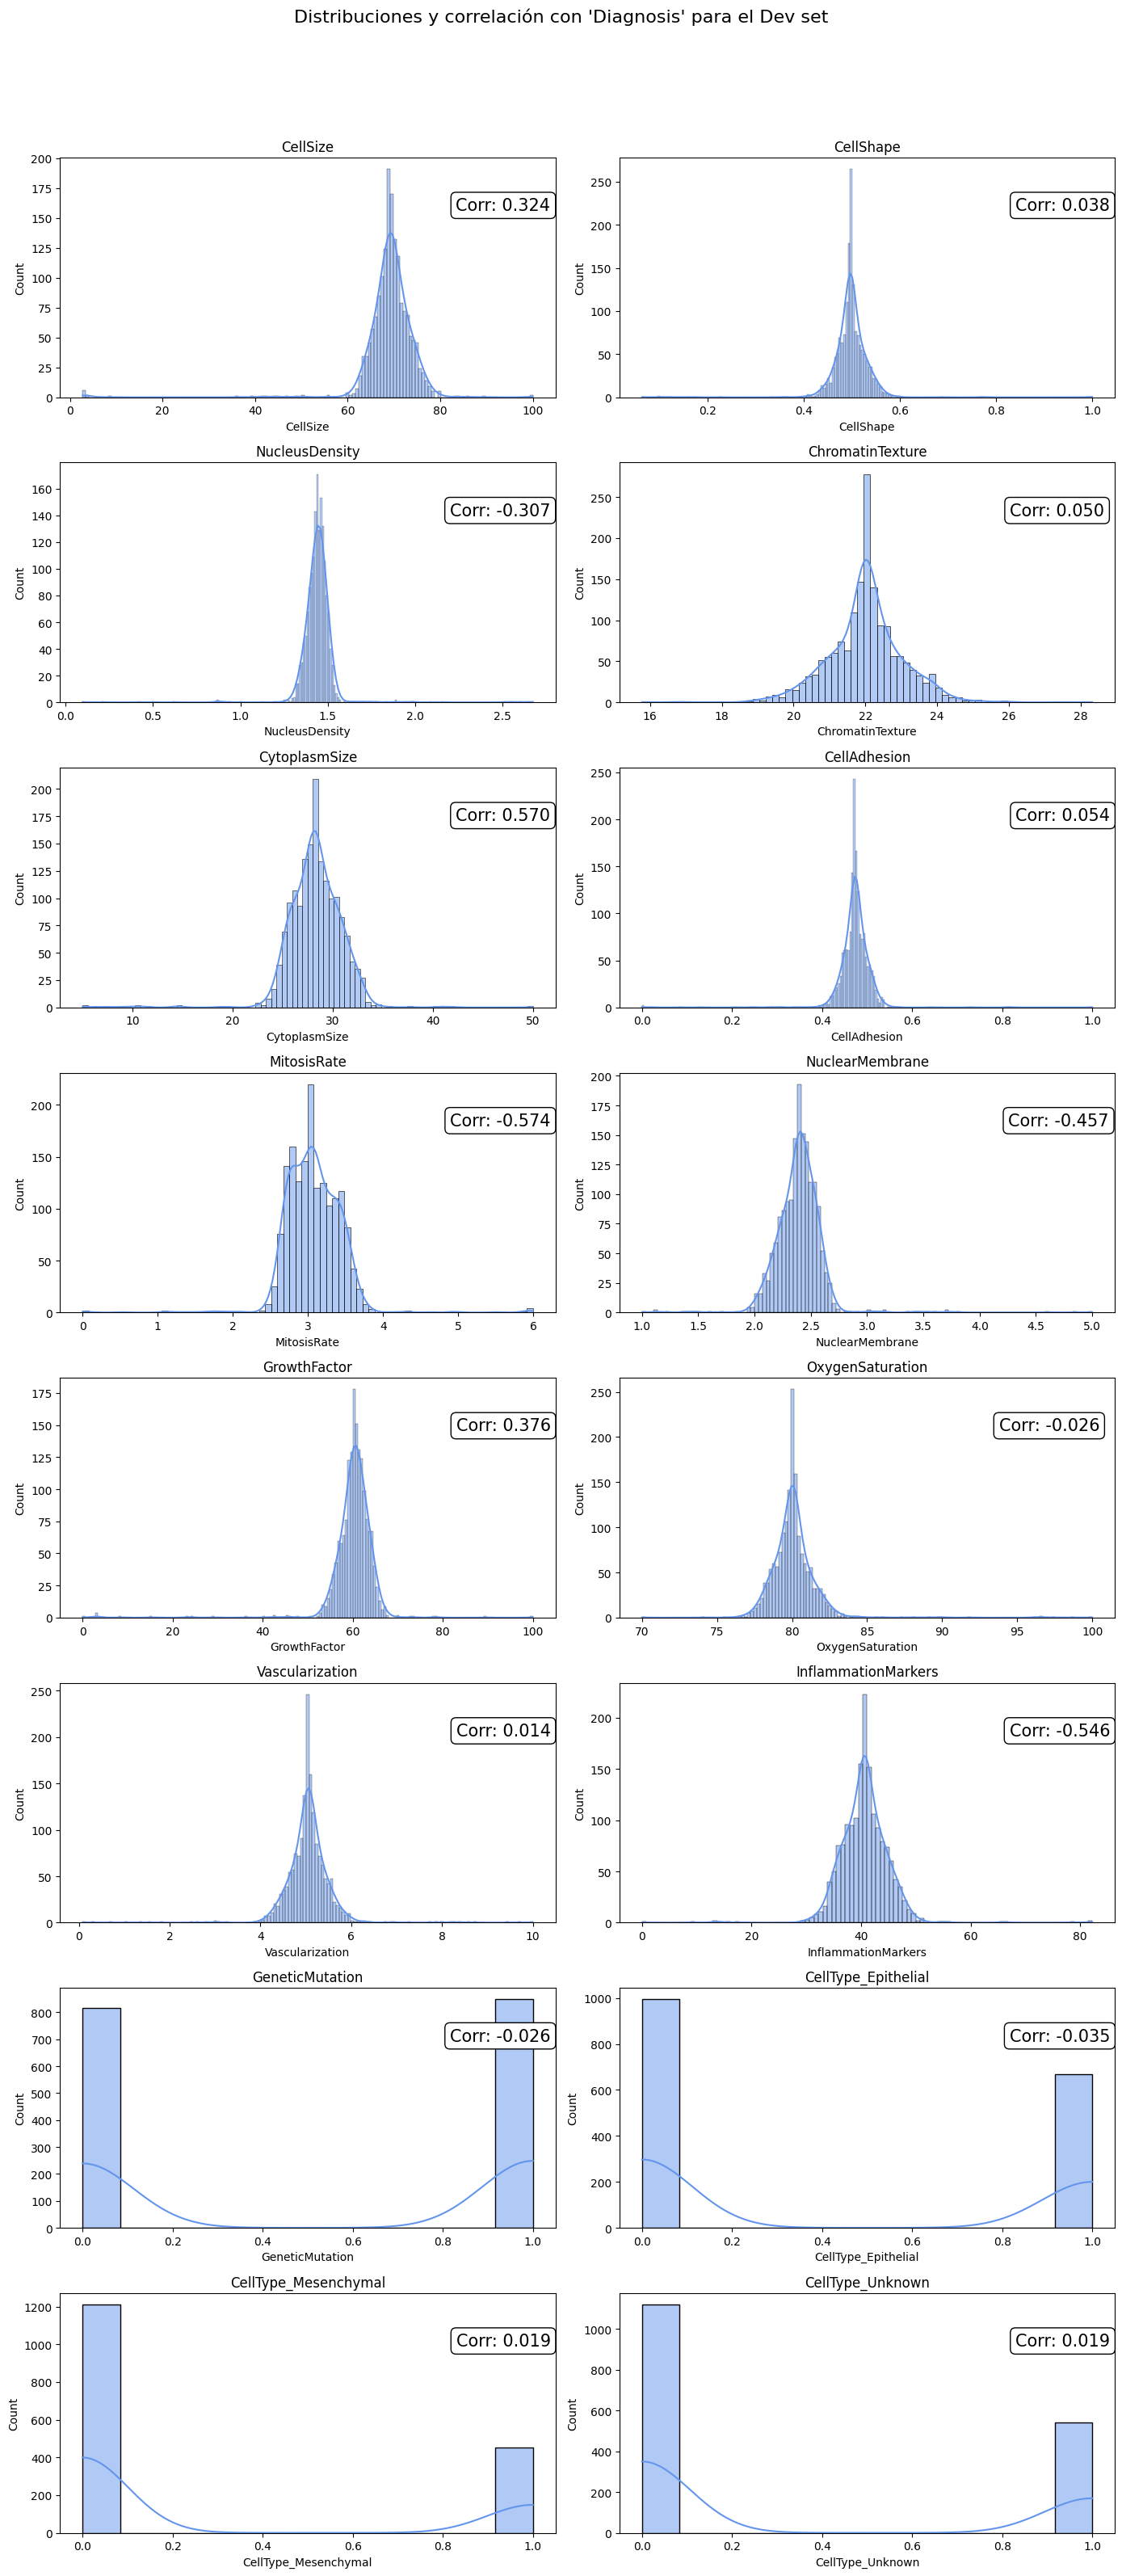

In [18]:
plot_features_with_correlation(diagnosis_dev_filled_OHE_BE, "Dev set", target_col="Diagnosis", batch_size=16)

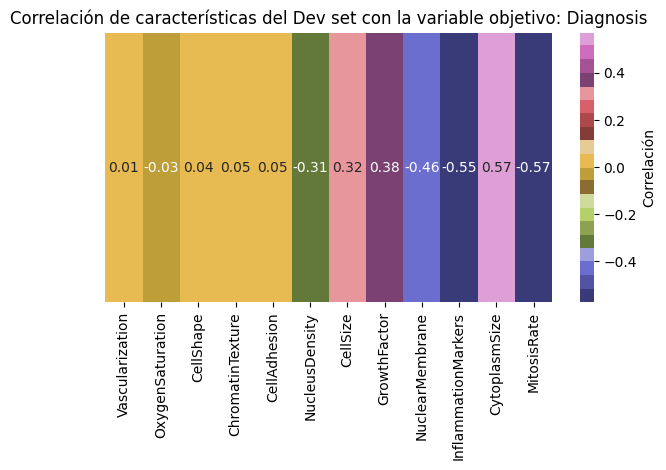

In [19]:
plot_correlations_with_target(diagnosis_dev_filled_OHE_BE, "Dev set", target_col="Diagnosis")

##### `Cell diagnosis `*`Imbalanced`*` Dev Set`

In [20]:
diagnosis_imbalanced_dev_filled = handle_missing_values(
    data=diagnosis_imbalanced_dev_df,
    target_col="Diagnosis",
    train=True,
    reference=None, # REVISAR SI LO HAGO CON ESTE O CON LAS STATS DEL DEV NORMAL
    intervals=valid_ranges,
    stats_dict=None,
    neighbors=5,
)

KNN imputing: 100%|██████████| 1139/1139 [00:01<00:00, 704.65it/s]


In [21]:
diagnosis_imbalanced_dev_filled_OHE = one_hot_encode_column(diagnosis_imbalanced_dev_filled, 'CellType', corrections=correcciones_celltype)

diagnosis_imbalanced_dev_filled_OHE_BE = binary_encode_column(diagnosis_imbalanced_dev_filled_OHE, 'GeneticMutation', mapeo_mutacion)

diagnosis_imbalanced_dev_filled_OHE_BE = convert_columns_to_int(diagnosis_imbalanced_dev_filled_OHE_BE, ['Diagnosis'])

c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\preprocessing.py:87: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[column] = df_copy[column].replace(mapping)


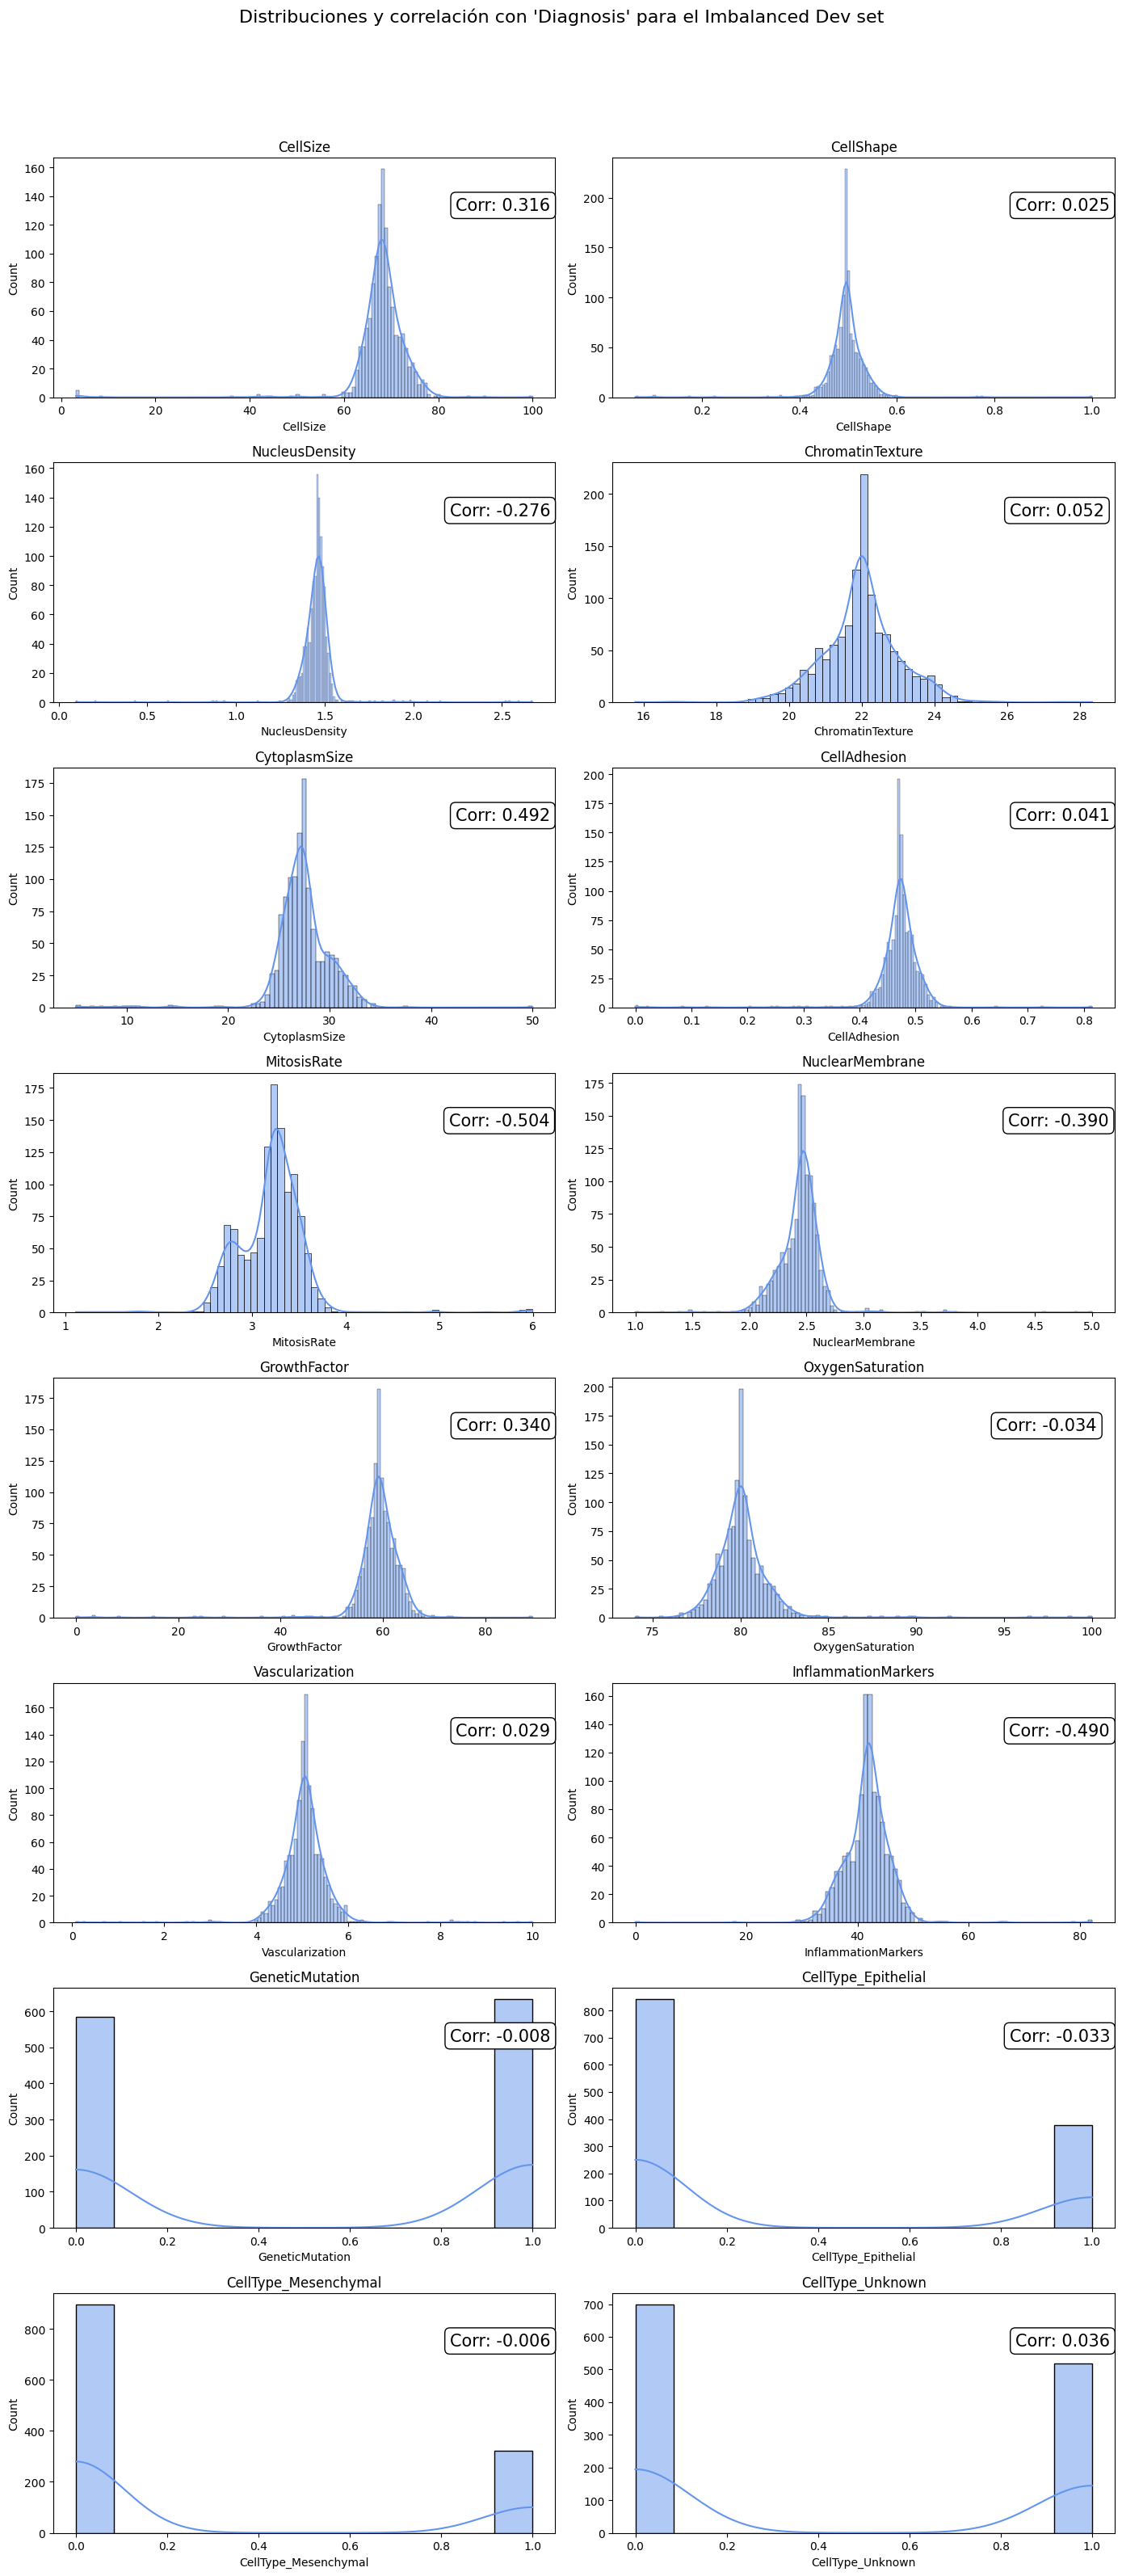

In [22]:
plot_features_with_correlation(diagnosis_imbalanced_dev_filled_OHE_BE, "Imbalanced Dev set", target_col="Diagnosis", batch_size=16)

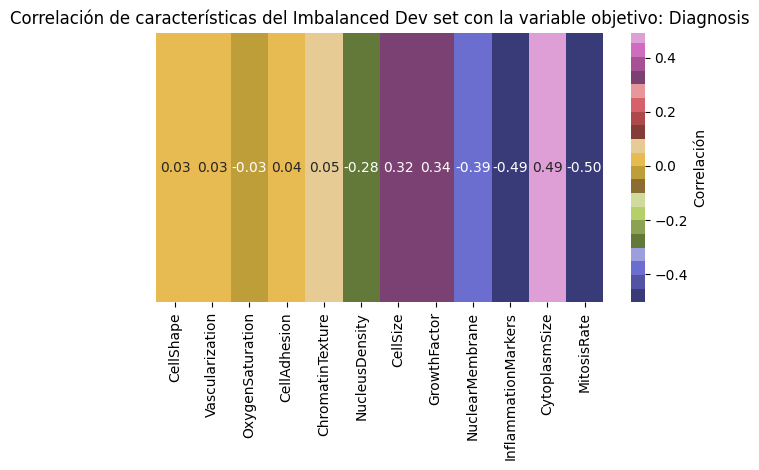

In [23]:
plot_correlations_with_target(diagnosis_imbalanced_dev_filled_OHE_BE, "Imbalanced Dev set", target_col="Diagnosis")

In [ ]:
from src.models import LogisticRegression
from src.metrics import report_metrics, plot_roc_curve, plot_pr_curve, f1_score
from src.preprocessing import normalize_dataframe
from src.data_splitting import split_train_validation

ImportError: cannot import name 'LogisticRegression' from 'src.models' (c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\models.py)

In [ ]:
# Constants
TARGET_COLUMN = "Diagnosis"


# 2. Dividir en entrenamiento y validación
diagnosis_train_df, diagnosis_val_df = split_train_validation(diagnosis_dev_filled_OHE_BE, val_ratio=0.2, seed=42)

# 3. Normalizar características (solo las numéricas, usando stats del train)
diagnosis_normalized_train, diagnosis_stats = normalize_dataframe(diagnosis_train_df, is_training=True, target_col=TARGET_COLUMN)
diagnosis_normalized_val, _ = normalize_dataframe(diagnosis_val_df, is_training=False, stats=diagnosis_stats, target_col=TARGET_COLUMN)

# 4. Separar características y etiquetas
diagnosis_X_train = diagnosis_normalized_train.drop(columns=[TARGET_COLUMN]).values
diagnosis_y_train = diagnosis_normalized_train[TARGET_COLUMN].values

diagnosis_X_val = diagnosis_normalized_val.drop(columns=[TARGET_COLUMN]).values
diagnosis_y_val = diagnosis_normalized_val[TARGET_COLUMN].values

# 5. Búsqueda del mejor lambda (L2 regularization)
best_f1 = -1
best_lambda = None
f1_scores = []
lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]

print("Tuning del hiperparámetro λ (L2):")
for lmbd in lambda_values:
    model = LogisticRegression(
        learning_rate=0.1,
        iterations=1000,
        regularization_strength=lmbd,
        plot_loss=False
    )
    model.fit(diagnosis_X_train, diagnosis_y_train)
    y_val_pred = model.predict(diagnosis_X_val)

    f1 = f1_score(diagnosis_y_val, y_val_pred)
    f1_scores.append(f1)

    print(f"λ = {lmbd:.2f} -> F1-score = {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_lambda = lmbd

# 6. Entrenamiento del modelo final con mejor λ
print(f"\nMejor λ encontrado: {best_lambda} (F1 = {best_f1:.4f})")

final_model = LogisticRegression(
    learning_rate=0.1,
    iterations=1000,
    regularization_strength=best_lambda,
    plot_loss=True
)
final_model.fit(diagnosis_X_train, diagnosis_y_train)

# 7. Evaluación final
y_scores = final_model.predict_proba(diagnosis_X_val)
y_pred = (y_scores >= 0.5).astype(int)

print("\nEvaluación en conjunto de validación:")
report_metrics(diagnosis_y_val, y_scores)

# 8. Curvas ROC y PR
plot_roc_curve(diagnosis_y_val, y_scores)
plot_pr_curve(diagnosis_y_val, y_scores)



KeyError: "['diagnosis'] not found in axis"